# Email Spam Detection with Machine Learning

**Objective:** Build a Natural Language Processing (NLP) binary classifier that distinguishes spam emails/SMS from legitimate (ham) messages.

**Dataset:** SMS Spam Collection Dataset (5,572 messages, labeled `ham` or `spam`), originally from the UCI Machine Learning Repository.

**Tech Stack:** Python, pandas, scikit-learn (TF-IDF, Naive Bayes, Logistic Regression), NLTK, Jupyter Notebook

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import re
import string
import warnings
warnings.filterwarnings('ignore')

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# NLP
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)

# ML
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

## 1. Load the Dataset

The dataset is loaded from `spam_data.csv`, which has two columns:
- `label`: `ham` (legitimate) or `spam`
- `message`: the raw SMS text

In [2]:
df = pd.read_csv('spam_data.csv')
print("Shape:", df.shape)
df.head(10)

Shape: (5572, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


In [3]:
# Check for nulls and duplicates
print("Null values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

# Remove exact duplicate messages
df = df.drop_duplicates().reset_index(drop=True)
print("\nShape after removing duplicates:", df.shape)

Null values:
 label      0
message    0
dtype: int64

Duplicate rows: 403

Shape after removing duplicates: (5169, 2)


## 2. Class Distribution Check

Before doing anything else, we check how balanced the dataset is between spam and ham.
This matters a lot: if spam is rare, a model that always predicts "ham" would still score high accuracy while being useless.

Counts:
 label
ham     4516
spam     653
Name: count, dtype: int64

Percentage:
 label
ham     87.37
spam    12.63
Name: proportion, dtype: float64


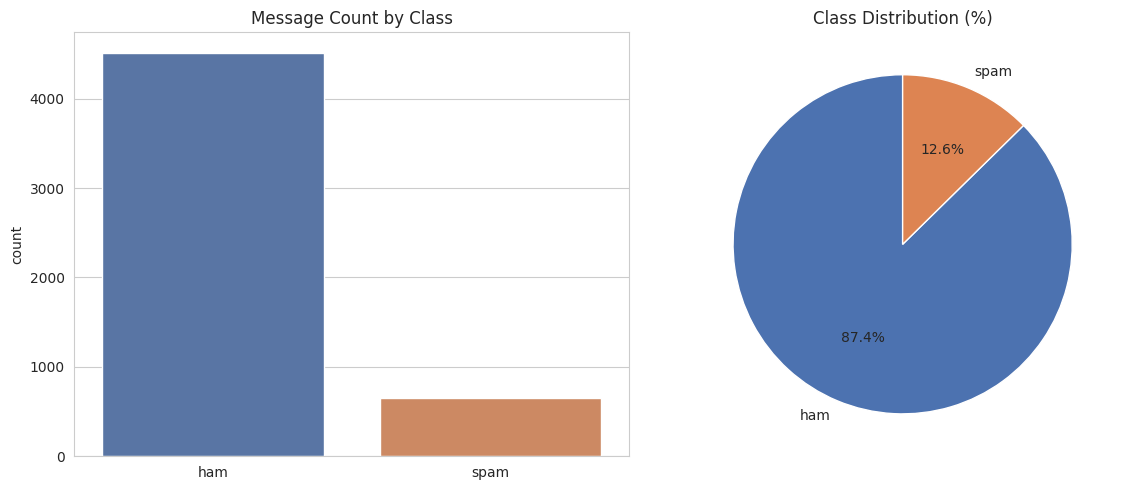

In [4]:
class_counts = df['label'].value_counts()
class_pct = df['label'].value_counts(normalize=True) * 100

print("Counts:\n", class_counts)
print("\nPercentage:\n", class_pct.round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(data=df, x='label', hue='label', palette=['#4C72B0', '#DD8452'], legend=False, ax=axes[0])
axes[0].set_title('Message Count by Class')
axes[0].set_xlabel('')

axes[1].pie(class_counts, labels=class_counts.index, autopct='%1.1f%%',
            colors=['#4C72B0', '#DD8452'], startangle=90)
axes[1].set_title('Class Distribution (%)')

plt.tight_layout()
plt.show()

**Observation:** The dataset is imbalanced — roughly 87% ham vs. 13% spam. This is realistic (most messages people receive are legitimate) but it means we need to look beyond plain accuracy when evaluating our models, and pay close attention to **recall** on the spam class (discussed later).

      message_length                                                           \
               count        mean        std   min    25%    50%    75%    max   
label                                                                           
ham           4516.0   70.459256  56.358207   2.0   34.0   52.0   90.0  910.0   
spam           653.0  137.891271  30.137753  13.0  132.0  149.0  157.0  224.0   

      word_count                                                      
           count       mean        std  min   25%   50%   75%    max  
label                                                                 
ham       4516.0  14.134632  11.116240  1.0   7.0  11.0  18.0  171.0  
spam       653.0  23.681470   5.967672  2.0  22.0  25.0  28.0   35.0  


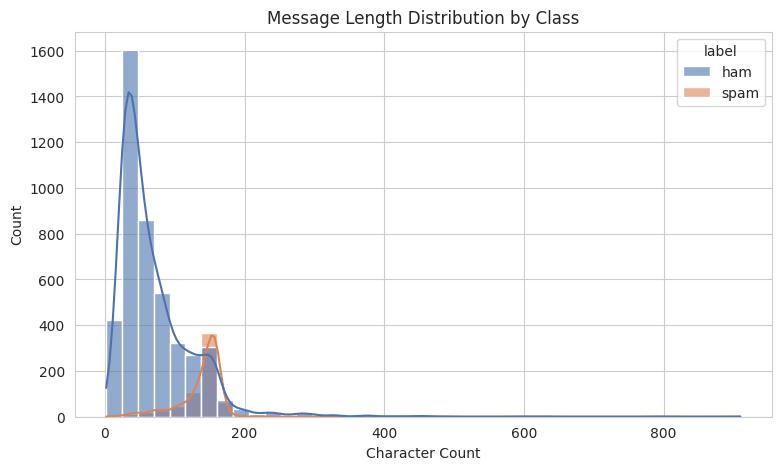

In [5]:
df['message_length'] = df['message'].apply(len)
df['word_count'] = df['message'].apply(lambda x: len(str(x).split()))

print(df.groupby('label')[['message_length', 'word_count']].describe())

fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(data=df, x='message_length', hue='label', bins=40, kde=True,
             palette=['#4C72B0', '#DD8452'], alpha=0.6)
ax.set_title('Message Length Distribution by Class')
ax.set_xlabel('Character Count')
plt.show()

**Observation:** Spam messages tend to be noticeably longer than ham messages on average — likely because spam often packs in promotional text, links, and call-to-action phrases.

## 3. Text Preprocessing Pipeline

We clean each message using a standard NLP pipeline:
1. **Lowercase conversion** — so "FREE" and "free" are treated the same
2. **Punctuation removal** — punctuation rarely carries predictive signal here
3. **Digit removal** — phone numbers/codes are replaced away to avoid overfitting on specific numbers
4. **Stopword removal** — common words like "the", "is", "and" add noise, not signal

In [6]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()                                   # lowercase
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)  # remove punctuation
    text = re.sub(r'\d+', '', text)                             # remove digits
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words]         # remove stopwords
    return ' '.join(tokens)

df['clean_message'] = df['message'].apply(clean_text)
df[['message', 'clean_message']].head(10)

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though
5,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey darling weeks word back id like fu...
6,Even my brother is not like to speak with me. ...,even brother like speak treat like aids patent
7,As per your request 'Melle Melle (Oru Minnamin...,per request melle melle oru minnaminunginte nu...
8,WINNER!! As a valued network customer you have...,winner valued network customer selected receiv...
9,Had your mobile 11 months or more? U R entitle...,mobile months u r entitled update latest colou...


## 4. WordCloud Visualisations (Bonus)

A quick visual gut-check: what words dominate spam vs. ham messages?

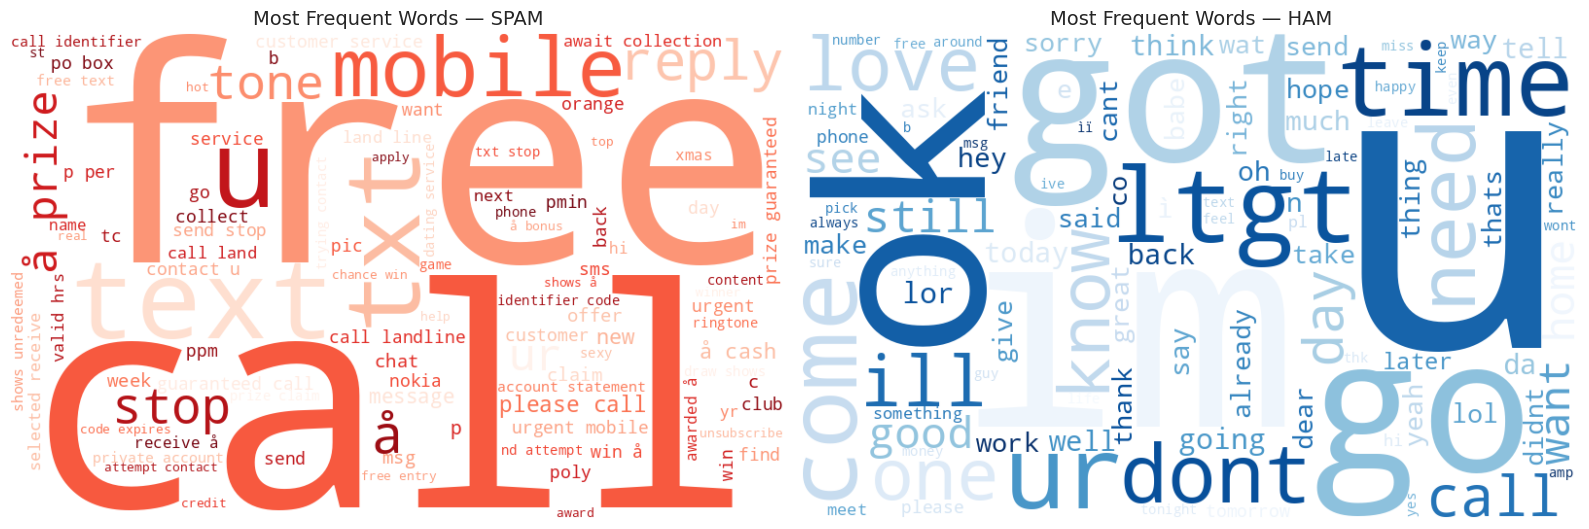

In [7]:
spam_text = ' '.join(df[df['label'] == 'spam']['clean_message'])
ham_text = ' '.join(df[df['label'] == 'ham']['clean_message'])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

wc_spam = WordCloud(width=800, height=500, background_color='white',
                     colormap='Reds', max_words=100).generate(spam_text)
axes[0].imshow(wc_spam, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Most Frequent Words — SPAM', fontsize=14)

wc_ham = WordCloud(width=800, height=500, background_color='white',
                    colormap='Blues', max_words=100).generate(ham_text)
axes[1].imshow(wc_ham, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Most Frequent Words — HAM', fontsize=14)

plt.tight_layout()
plt.show()

**Observation:** Spam messages are dominated by words like *free*, *call*, *txt*, *win*, *mobile*, *claim* and *prize* — classic promotional/urgency language. Ham messages instead feature everyday conversational words like *im*, *ok*, *go*, *know*, *love*, *good*.

## 5. Feature Extraction — TF-IDF Vectorizer

**What TF-IDF measures:** TF-IDF (Term Frequency – Inverse Document Frequency) converts text into numerical vectors that reflect how *important* a word is to a specific message relative to the whole dataset.

- **Term Frequency (TF)** measures how often a word appears within a single message.
- **Inverse Document Frequency (IDF)** down-weights words that appear in *many* messages (e.g., common words carry less discriminating power) and up-weights rarer, more distinctive words.
- The product, **TF-IDF**, gives high scores to words that are frequent in a specific message but rare across the whole corpus — exactly the kind of words (e.g., "winner", "claim", "urgent") that help distinguish spam from ham.

We cap the vocabulary at 3,000 features to keep the model efficient and reduce overfitting on rare words.

In [8]:
tfidf = TfidfVectorizer(max_features=3000)

X = df['clean_message']
y = df['label'].map({'ham': 0, 'spam': 1})  # spam = 1 (positive class)

print("Label encoding: ham -> 0, spam -> 1")
print(y.value_counts())

Label encoding: ham -> 0, spam -> 1
label
0    4516
1     653
Name: count, dtype: int64


## 6. Train/Test Split

We split the data 80/20, stratifying on the label so both spam and ham are proportionally represented in the train and test sets.

In [9]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train_text.shape[0])
print("Test size:", X_test_text.shape[0])

# Fit TF-IDF on training data only, then transform both sets (avoids data leakage)
X_train = tfidf.fit_transform(X_train_text)
X_test = tfidf.transform(X_test_text)

print("TF-IDF feature matrix shape (train):", X_train.shape)

Train size: 4135
Test size: 1034
TF-IDF feature matrix shape (train): (4135, 3000)


## 7. Train Classifiers

We train **two classifiers** as required:
1. **Multinomial Naive Bayes** — the industry-standard baseline for text classification. It works well with TF-IDF/count features and is fast to train.
2. **Logistic Regression** — a strong linear alternative that often performs competitively on high-dimensional sparse text data.

In [10]:
# Model 1: Multinomial Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_preds = nb_model.predict(X_test)

# Model 2: Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

print("Both models trained successfully.")

Both models trained successfully.


## 8. Model Evaluation

For each model we report **accuracy, precision, recall, F1-score**, and a **confusion matrix**.

Since the positive class (`spam` = 1) is the minority class, precision and recall on spam specifically matter more than the overall accuracy number.

In [11]:
def evaluate_model(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    print(f"--- {name} ---")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}  (of messages flagged as spam, how many were truly spam)")
    print(f"Recall   : {rec:.4f}  (of all true spam, how many did we catch)")
    print(f"F1-score : {f1:.4f}")
    print()
    print(classification_report(y_true, y_pred, target_names=['ham', 'spam']))
    return {'model': name, 'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}

results = []
results.append(evaluate_model("Multinomial Naive Bayes", y_test, nb_preds))
results.append(evaluate_model("Logistic Regression", y_test, lr_preds))

--- Multinomial Naive Bayes ---
Accuracy : 0.9710
Precision: 0.9903  (of messages flagged as spam, how many were truly spam)
Recall   : 0.7786  (of all true spam, how many did we catch)
F1-score : 0.8718

              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       903
        spam       0.99      0.78      0.87       131

    accuracy                           0.97      1034
   macro avg       0.98      0.89      0.93      1034
weighted avg       0.97      0.97      0.97      1034

--- Logistic Regression ---
Accuracy : 0.9584
Precision: 0.9889  (of messages flagged as spam, how many were truly spam)
Recall   : 0.6794  (of all true spam, how many did we catch)
F1-score : 0.8054

              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       903
        spam       0.99      0.68      0.81       131

    accuracy                           0.96      1034
   macro avg       0.97      0.84      0.89      

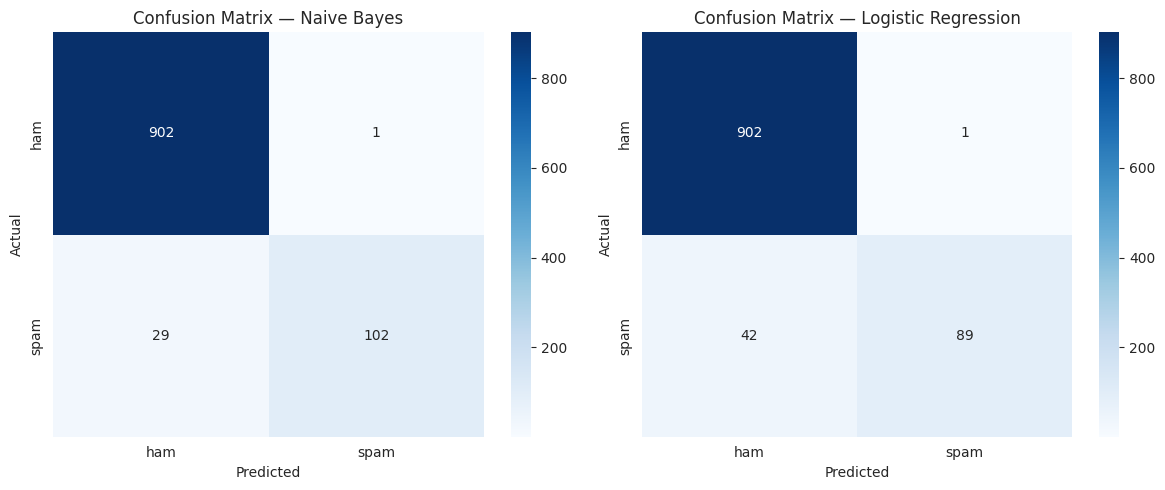

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, preds, name in zip(axes, [nb_preds, lr_preds], ['Naive Bayes', 'Logistic Regression']):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['ham', 'spam'], yticklabels=['ham', 'spam'])
    ax.set_title(f'Confusion Matrix — {name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [13]:
results_df = pd.DataFrame(results).set_index('model').round(4)
results_df

,accuracy,precision,recall,f1
model,,,,
Multinomial Naive Bayes,0.9710,0.9903,0.7786,0.8718
Logistic Regression,0.9584,0.9889,0.6794,0.8054


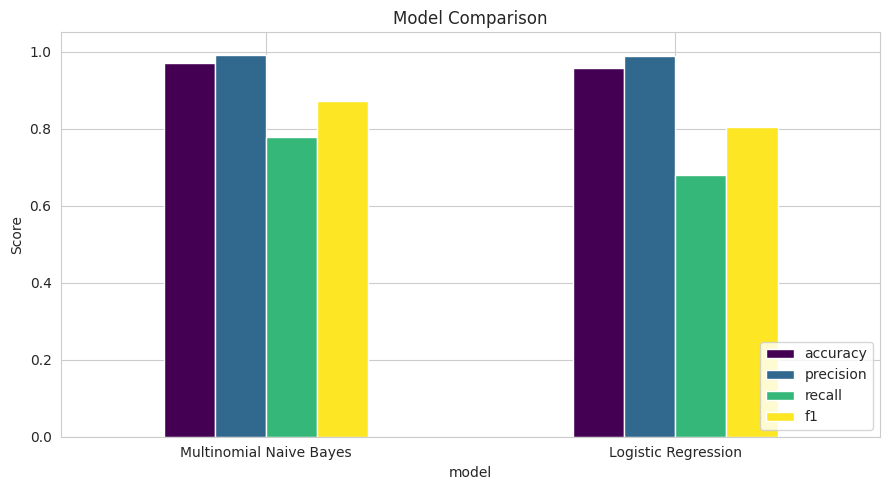

In [14]:
results_df[['accuracy', 'precision', 'recall', 'f1']].plot(kind='bar', figsize=(9, 5), colormap='viridis')
plt.title('Model Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0, 1.05)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 9. Discussion — Why is Recall Particularly Important for Spam Detection?

In spam detection, the two classifiers can make two different kinds of mistakes:

- **False Positive** (a *ham* message wrongly flagged as spam) — a legitimate message gets buried in the spam folder. This can mean a user misses an important email/OTP/message.
- **False Negative** (a *spam* message wrongly classified as ham) — spam reaches the inbox. This is annoying but rarely catastrophic for the user.

At first glance this seems to argue for prioritising **precision** (minimizing false positives) so we never lose a real message. However, in practice, most production spam filters are tuned with a strong **recall** floor for a few reasons:

1. **Asymmetric cost in security contexts:** Spam is often the delivery mechanism for phishing, malware, or financial scams. A missed spam message (low recall) isn't just "clutter" — it's a potential attack that reaches the user. Missing a *dangerous* spam message can be far more costly than the mild inconvenience of a ham message occasionally being misfiled.
2. **Recall measures how much spam we actually catch.** A model with high precision but low recall might correctly identify spam *only when it's very confident*, letting a large fraction of clever/borderline spam slip through — which defeats the purpose of a spam filter.
3. **In practice, systems balance both**, often using a threshold that leans toward higher recall for spam while keeping precision "good enough" that false positives stay rare (since TF-IDF + a well-regularised classifier already tends to keep false positives low, as seen in our confusion matrices above).

**Conclusion:** For this task, we prioritize **recall on the spam class** as the primary metric to optimize, while still monitoring precision to make sure we aren't sacrificing too many legitimate messages in the process.

## 10. Best Model & Error Analysis

In [15]:
best_model_name = results_df['recall'].idxmax()
print(f"Model with the highest spam recall: {best_model_name}")
results_df

Model with the highest spam recall: Multinomial Naive Bayes


,accuracy,precision,recall,f1
model,,,,
Multinomial Naive Bayes,0.9710,0.9903,0.7786,0.8718
Logistic Regression,0.9584,0.9889,0.6794,0.8054


In [16]:
# Show a few misclassified examples from the Naive Bayes model for qualitative error analysis
test_df = pd.DataFrame({
    'message': X_test_text.values,
    'actual': y_test.values,
    'predicted_nb': nb_preds,
    'predicted_lr': lr_preds
})

misclassified_nb = test_df[test_df['actual'] != test_df['predicted_nb']]
print(f"Naive Bayes misclassified {len(misclassified_nb)} out of {len(test_df)} test messages.")
misclassified_nb[['message', 'actual', 'predicted_nb']].head(10)

Naive Bayes misclassified 30 out of 1034 test messages.


,message,actual,predicted_nb
79,thanks vote sing along stars karaoke mobile fr...,1,0
112,send logo ur lover names joined heart txt love...,1,0
125,congrats year special cinema pass call c suprm...,1,0
160,hi babe jordan r u im home abroad lonely text ...,1,0
168,hi ur lookin saucy daytime fun wiv busty marri...,1,0
174,themobhit link get premium pink panther game n...,1,0
223,guess somebody know secretly fancies wanna fin...,1,0
230,asked mobile chatlines inclu free mins india c...,1,0
308,hi lucy hubby meetins day fri b alone hotel u ...,1,0
326,missed call alert numbers called left message,1,0


## 11. Conclusion

- Both **Multinomial Naive Bayes** and **Logistic Regression** perform strongly on this dataset after TF-IDF vectorization, achieving high accuracy (>95%) despite the class imbalance.
- **Naive Bayes** is the traditional go-to for text classification and trains almost instantly, making it a great lightweight baseline.
- **Logistic Regression** offers a competitive, interpretable alternative and can be tuned further (e.g., regularization strength, class weights) to push recall even higher if needed.
- Given the discussion above, the model with the **better recall on the spam class** would be preferred as the production choice for an actual spam filter, provided its precision remains acceptable.
- Further improvements could include: n-gram features (bigrams/trigrams), stemming/lemmatization, oversampling with SMOTE, or ensemble methods (e.g., combining NB + LR predictions).